# Laboratorio 6 — Análisis de redes sociales (YouTube)

In [1]:
import json
import re
import warnings
from collections import Counter
from itertools import islice

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx

warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)

RANDOM_STATE = 42
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 160)

## 1. Carga, comprensión e integración de los datos

In [2]:
videos = pd.read_csv("data/youtube_videos.csv", encoding="utf-8")
comments = pd.read_csv("data/youtube_comments.csv", encoding="utf-8")

print("youtube_videos.csv ->", videos.shape)
print("youtube_comments.csv ->", comments.shape)

youtube_videos.csv -> (293, 20)
youtube_comments.csv -> (406, 17)


### 1.1 Carga

Ambos archivos se cargan con `pandas.read_csv` usando codificación UTF-8, que es
la codificación en la que están guardados los archivos originales.

In [3]:
videos.head(3)

,video_id,title,channel_name,channel_id,source_query,source_group,dataset_sources,channel_handle,published_time,view_count_text,description_snippet,video_url,query_hits,keywords,description,view_count,publish_date,upload_date,category,owner_handle
0,-5puKGEqcUc,INSIVUMEH pronostica incremento de lluvias par...,T13 Noticias Guatemala,UCq0Cm-3SKthEySQc2JZBi1A,guatemala lluvias,topic,youtube_guatemala.csv | youtube_guatemala_lab....,/@T13NoticiasGuatemala,hace 2 días,"2,390 vistas",El Departamento de Pronóstico de INSIVUMEH pre...,https://www.youtube.com/watch?v=-5puKGEqcUc,"[""guatemala lluvias""]","[""Canícula prolongada"", ""Chapin tv"", ""Fenómeno...",El Departamento de Pronóstico de INSIVUMEH pre...,2357,2026-08-28T22:00:20-07:00,2026-08-28T22:00:20-07:00,News & Politics,/@T13NoticiasGuatemala
1,-E7OPOLjMug,BERNARDO ARÉVALO CALIFICA CAMBIO EN EL MP COMO...,IDocumenta,UCgItjn_ZWFWcv1MlpKIkqgQ,@GobiernodelaRepublicadeGuatema,topic,youtube_target_channels.csv,/@iDocumenta,hace 3 meses,4 vistas,"El presidente de Guatemala, Bernardo Arévalo, ...",https://www.youtube.com/watch?v=-E7OPOLjMug,"[""@GobiernodelaRepublicadeGuatema""]",[],"El presidente de Guatemala, Bernardo Arévalo, ...",4,2026-05-13T16:00:03-07:00,2026-05-13T16:00:03-07:00,People & Blogs,/@iDocumenta
2,-KDglrIzRKo,¡HISTÓRICO! Mexico recupera petróleo robado po...,México Poder,UC-DpoeBbCMOMOH1-j71KPqA,guatemala noticias,topic,youtube_guatemala.csv | youtube_guatemala_lab....,/@M%C3%A9xicoPoder,hace 1 día,"29,736 vistas",México #PetróleoMexicano #SoberaníaEnergética ...,https://www.youtube.com/watch?v=-KDglrIzRKo,"[""guatemala noticias""]","[""Mexico recupera petroleo"", ""petroleo robado ...",#México #PetróleoMexicano #SoberaníaEnergética...,29736,2026-08-29T17:00:38-07:00,2026-08-29T17:00:38-07:00,People & Blogs,/@M%C3%A9xicoPoder


In [4]:
comments.head(3)

,video_id,comment_id,video_title,channel_name,channel_id,author_name,author_channel_id,text,source_query,source_group,dataset_sources,author_handle,published_text,like_count_text,reply_count,is_pinned,viewer_rating
0,j43HgwYFKfk,Ugw-J65a1iYL9hqhELh4AaABAg,La cooptación de Walter Mazariegos en la USAC,Quorum,UCE4rsXcgDb6e1-a9iTbWzfg,@MarcosCarillo-b1r,UCdFlugHJJa4l3YqWuNRmvXw,Ese corrupto amigo de la vieja fiscal los teng...,@quorumgt,topic,j43HgwYFKfk_out_comments.csv | quorum_complete...,/@MarcosCarillo-b1r,hace 6 meses,,0,False,NaN
1,06mFNPU0aB8,Ugw-ZT9t9wU2V-tCaUZ4AaABAg,Capturan a presuntos delincuentes disfrazados ...,Noti7,UCVpSRoZgngfSL03Nlbjtq9A,@RaulPerez-cw2vi,UCvl1tzQeBeGy6efPTRJXSCw,"Están jóvenes porque no buscan un trabajo, tu...",guatemala noticias,topic,youtube_guatemala_comments.csv | youtube_guate...,/@RaulPerez-cw2vi,hace 2 semanas,,0,False,NaN
2,j43HgwYFKfk,Ugw0xaOb2CYXXoudtwJ4AaABAg,La cooptación de Walter Mazariegos en la USAC,Quorum,UCE4rsXcgDb6e1-a9iTbWzfg,@iamjimalesssa,UCRAquv8el-tQ30bN7MlmySQ,Me dejaron con ganas de demandar la ilegalidad...,@quorumgt,topic,j43HgwYFKfk_out_comments.csv | quorum_complete...,/@iamjimalesssa,hace 1 año,4,0,False,NaN


### 1.2 Unidad de observación, llave primaria y variables relevantes

**`youtube_videos.csv`**
- Unidad de observación: **un video de YouTube**.
- Llave primaria: `video_id` (única, sin duplicados — se verifica abajo).
- Variables relevantes: `channel_id` (identificador estable del canal),
  `title`/`description`/`keywords` (contenido para análisis de texto y temas),
  `view_count` (popularidad), `category` (tema editorial asignado por YouTube),
  `source_query`/`source_group` (procedimiento de muestreo, no el tema real del
  video), `publish_date` (fecha exacta de publicación).

**`youtube_comments.csv`**
- Unidad de observación: **un comentario principal publicado en un video**.
- Llave primaria: `comment_id` (única, sin duplicados — se verifica abajo).
- Llave foránea hacia `youtube_videos.csv`: `video_id`.
- Variables relevantes: `author_channel_id` (identificador estable del autor,
  se usará como nodo en la red), `text` (contenido para análisis de tópicos y
  sentimiento), `like_count_text` y `reply_count` (intensidad de reacción a un
  comentario).

In [5]:
print("video_id duplicados en videos:", videos["video_id"].duplicated().sum())
print("comment_id duplicados en comments:", comments["comment_id"].duplicated().sum())

video_id duplicados en videos: 0
comment_id duplicados en comments: 0


### 1.3 Relación entre canal, video, autor, comentario, categoría y consulta de búsqueda

```
channel (channel_id) ---publica---> video (video_id) ---categoria---> category
                                        |
                                        | recuperado mediante
                                        v
                              source_query / source_group
                                        |
                                        | recibe comentarios de
                                        v
                 author (author_channel_id) ---escribe---> comment (comment_id)
```

- Un **canal** (`channel_id`) publica cero o más **videos** (`video_id`); la
  relación canal→video es 1→N.
- Cada video tiene asignada una **categoría** editorial de YouTube (`category`)
  y fue recuperado mediante una o varias **consultas de búsqueda**
  (`source_query`, y de forma más granular `query_hits`); esto describe el
  *muestreo*, no necesariamente el tema real del contenido.
- Un **autor** (`author_channel_id`) es una cuenta de YouTube distinta del
  canal que publicó el video comentado; un autor puede escribir uno o varios
  **comentarios** (`comment_id`) y, potencialmente, comentar en más de un
  video. La relación autor→comentario es 1→N; la relación
  autor↔video (a través de los comentarios) es N↔M y es precisamente la que
  se modela como red bipartita en el ejercicio 4.
- **Importante:** el canal que sube el video y el autor que comenta son
  entidades distintas (`channel_id` vs. `author_channel_id`); no deben
  confundirse aunque ambas sean "cuentas de YouTube".

### 1.4 Integración mediante `video_id`

In [6]:
comments_videos = comments.merge(
    videos, on="video_id", how="left", suffixes=("_comment", "_video"), indicator=True
)

match_counts = comments_videos["_merge"].value_counts()
print(match_counts)

n_matched = (comments_videos["_merge"] == "both").sum()
print(f"\nComentarios que pudieron asociarse con un video: {n_matched} de {len(comments)} "
      f"({n_matched / len(comments):.1%})")

_merge
both          406
left_only       0
right_only      0
Name: count, dtype: int64

Comentarios que pudieron asociarse con un video: 406 de 406 (100.0%)


In [7]:
videos_con_comentarios = comments["video_id"].nunique()
print(f"Videos distintos que aparecen en youtube_comments.csv: {videos_con_comentarios}")
print(f"Videos totales en youtube_videos.csv: {videos.shape[0]}")
print(f"Proporción de videos con al menos un comentario en la muestra: "
      f"{videos_con_comentarios / videos.shape[0]:.1%}")

Videos distintos que aparecen en youtube_comments.csv: 19
Videos totales en youtube_videos.csv: 293
Proporción de videos con al menos un comentario en la muestra: 6.5%


**Hallazgo clave para el resto del laboratorio:** el 100 % de los comentarios
(406/406) se asocian correctamente con un `video_id` presente en
`youtube_videos.csv`. Sin embargo, esos 406 comentarios se concentran en
**solo 19 de los 293 videos** (≈6.5 %). Es decir, la recolección de
comentarios fue selectiva y no cubrió todos los videos muestreados. Esto es
una limitación estructural que condiciona directamente la red bipartita del
ejercicio 4: la mayoría de los videos del dataset de videos nunca podrán
aparecer como nodo en la red autor–video porque no tienen comentarios
asociados.

## 2. Calidad, limpieza y preprocesamiento

### 2.1 Diagnóstico inicial de calidad

In [8]:
def resumen_calidad(df, nombre):
    resumen = pd.DataFrame({
        "dtype": df.dtypes.astype(str),
        "n_faltantes": df.isna().sum(),
        "pct_faltantes": (df.isna().mean() * 100).round(1),
        "n_unicos": df.nunique(),
        "es_constante": df.nunique(dropna=False) <= 1,
    })
    print(f"--- {nombre}: {df.shape[0]} filas x {df.shape[1]} columnas ---")
    return resumen

resumen_videos = resumen_calidad(videos, "youtube_videos.csv")
resumen_videos

--- youtube_videos.csv: 293 filas x 20 columnas ---


,dtype,n_faltantes,pct_faltantes,n_unicos,es_constante
video_id,str,0,0.0,293,False
title,str,0,0.0,274,False
channel_name,str,0,0.0,97,False
channel_id,str,0,0.0,97,False
source_query,str,0,0.0,21,False
source_group,str,0,0.0,3,False
dataset_sources,str,0,0.0,23,False
channel_handle,str,0,0.0,97,False
published_time,str,13,4.4,80,False
view_count_text,str,13,4.4,259,False


In [9]:
resumen_comments = resumen_calidad(comments, "youtube_comments.csv")
resumen_comments

--- youtube_comments.csv: 406 filas x 17 columnas ---


,dtype,n_faltantes,pct_faltantes,n_unicos,es_constante
video_id,str,0,0.0,19,False
comment_id,str,0,0.0,406,False
video_title,str,0,0.0,19,False
channel_name,str,0,0.0,8,False
channel_id,str,0,0.0,8,False
author_name,str,0,0.0,332,False
author_channel_id,str,0,0.0,332,False
text,str,0,0.0,404,False
source_query,str,0,0.0,6,False
source_group,str,0,0.0,2,False


**Dimensiones:** 293 videos x 20 variables, 406 comentarios x 17 variables
(consistente con la ficha técnica del laboratorio).

**Valores faltantes:** en `videos`, `description_snippet` (25), `description`
(26), `published_time`/`view_count_text` (13 cada una) presentan nulos; el
resto de columnas está completo. En `comments` no hay valores nulos
representados como `NaN` en ninguna columna **excepto** `viewer_rating`, que
está vacía en el 100 % de los 406 registros.

**Duplicados:** no existen filas completamente duplicadas ni duplicados de
`video_id` en `videos` ni de `comment_id` en `comments` (verificado en 1.2).
Sí existen registros con el mismo `author_channel_id` y `video_id` (un mismo
autor comentando varias veces el mismo video), lo cual es válido y se
convierte en el peso de la arista en la red bipartita.

**Variables constantes:** `is_pinned` toma el valor `False` en el 100 % de
los registros (0 varianza) y `viewer_rating` está vacía en el 100 % de los
registros.

In [10]:
print("is_pinned valores únicos:", comments["is_pinned"].unique())
print("viewer_rating no nulos:", comments["viewer_rating"].notna().sum(), "de", len(comments))

is_pinned valores únicos: [False]
viewer_rating no nulos: 0 de 406


**Valores atípicos (outliers):** `view_count` y `like_count` (una vez
convertida a numérica en 2.4) tienen distribuciones muy sesgadas a la derecha,
típicas de fenómenos de popularidad en redes sociales (unos pocos videos con
visualizaciones extremas). Se visualiza en escala logarítmica para no ocultar
la mayoría de las observaciones detrás de unos pocos valores extremos.

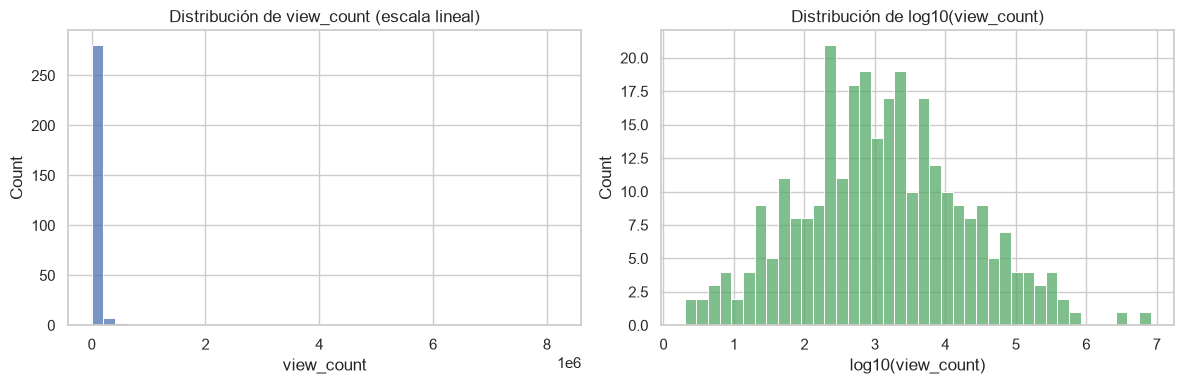

count    2.930000e+02
mean     6.043009e+04
std      5.157983e+05
min      2.000000e+00
25%      2.150000e+02
50%      1.175000e+03
75%      7.465000e+03
max      8.190449e+06
Name: view_count, dtype: float64


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(videos["view_count"], bins=40, ax=axes[0], color="#4C72B0")
axes[0].set_title("Distribución de view_count (escala lineal)")
sns.histplot(np.log10(videos["view_count"].clip(lower=1)), bins=40, ax=axes[1], color="#55A868")
axes[1].set_title("Distribución de log10(view_count)")
axes[1].set_xlabel("log10(view_count)")
plt.tight_layout()
plt.show()

print(videos["view_count"].describe())

**Consistencia entre identificadores, nombres y handles:**
- `channel_id` ↔ `channel_name`: 97 valores únicos de cada uno en `videos`, y
  ningún `channel_id` está asociado a más de un `channel_name` distinto en
  este corte de datos. Aun así, se conserva `channel_id` como identificador
  porque la documentación advierte que el nombre visible puede cambiar.
- `author_channel_id` ↔ `author_name` en `comments`: 332 valores únicos de
  cada uno, con correspondencia 1 a 1 en esta muestra.
- `channel_handle` y `owner_handle` son idénticos en el 100 % de las filas de
  `videos`; `upload_date` y `publish_date` también son idénticos en el 100 %
  de las filas. Ambos pares de columnas son redundantes entre sí.

In [12]:
chk = pd.DataFrame({
    "channel_id_unicos": [videos["channel_id"].nunique()],
    "channel_name_unicos": [videos["channel_name"].nunique()],
    "channel_id_con_mas_de_1_nombre": [(videos.groupby("channel_id")["channel_name"].nunique() > 1).sum()],
    "author_channel_id_unicos": [comments["author_channel_id"].nunique()],
    "author_name_unicos": [comments["author_name"].nunique()],
    "channel_handle_igual_owner_handle_pct": [(videos["channel_handle"] == videos["owner_handle"]).mean()],
    "upload_date_igual_publish_date_pct": [(videos["upload_date"] == videos["publish_date"]).mean()],
})
chk.T

,0
channel_id_unicos,97.0
channel_name_unicos,97.0
channel_id_con_mas_de_1_nombre,0.0
author_channel_id_unicos,332.0
author_name_unicos,332.0
channel_handle_igual_owner_handle_pct,1.0
upload_date_igual_publish_date_pct,1.0


### 2.2 Variables problemáticas o de uso delicado

| Variable | Problema | Tratamiento |
|---|---|---|
| `viewer_rating` | 100 % vacía | Se excluye del análisis; no aporta información. |
| `is_pinned` | Constante (`False`) | Se excluye de cualquier modelo o comparación; no discrimina. |
| `published_time` (videos) / `published_text` (comments) | Tiempo **relativo** a la fecha de recolección (p. ej. "hace 2 días"), no una fecha exacta. La fecha de recolección no está registrada de forma explícita para los comentarios. | No se convierte a fecha absoluta; se usa únicamente de forma cualitativa (orden aproximado) y se documenta como limitación temporal en la sección 10. |
| `description_snippet` | Fragmento truncado y redundante de `description`; tiene nulos que no implican ausencia real de descripción. | Se prioriza `description` completa; `description_snippet` no se usa como fuente de texto. |
| `upload_date` / `channel_handle` / `owner_handle` | Idénticas a `publish_date` / `owner_handle` / `channel_handle` respectivamente en el 100 % de los casos | Se conserva solo una de cada par para evitar redundancia; no se eliminan físicamente las columnas por trazabilidad, pero no se usan ambas en el mismo análisis. |
| `query_hits`, `keywords`, `dataset_sources` | Almacenadas como texto con estructura de lista (`["a", "b"]` o `"a \| b"`) | Se parsean explícitamente a listas de Python antes de usarlas (ver 2.3). |
| `like_count_text` | Texto que puede estar vacío | Se convierte a numérico documentando el tratamiento de vacíos (ver 2.4). |
| `reply_count` | **No debe interpretarse como arista entre usuarios** (ver advertencia del enunciado) | Se usa únicamente como atributo descriptivo del comentario, nunca para construir relaciones autor–autor. |

### 2.3 Normalización de identificadores y nombres

Se conservan `channel_id`, `video_id`, `comment_id` y `author_channel_id`
como identificadores en todas las tablas y en la red. Los nombres visibles
(`channel_name`, `author_name`, handles) se guardan únicamente como
**atributos descriptivos** en tablas de referencia (lookups), nunca como
llave de unión ni como identificador de nodo.

In [13]:
def parse_lista(valor):
    """Convierte una columna con estructura de lista en texto a una lista de Python."""
    if pd.isna(valor):
        return []
    valor = str(valor).strip()
    if valor.startswith("["):
        try:
            return json.loads(valor)
        except json.JSONDecodeError:
            return []
    return [v.strip() for v in valor.split("|") if v.strip()]

videos["keywords_lista"] = videos["keywords"].apply(parse_lista)
videos["query_hits_lista"] = videos["query_hits"].apply(parse_lista)
videos["dataset_sources_lista"] = videos["dataset_sources"].apply(parse_lista)
comments["dataset_sources_lista"] = comments["dataset_sources"].apply(parse_lista)

videos[["keywords", "keywords_lista"]].head(3)

,keywords,keywords_lista
0,"[""Canícula prolongada"", ""Chapin tv"", ""Fenómeno...","[Canícula prolongada, Chapin tv, Fenómeno del ..."
1,[],[]
2,"[""Mexico recupera petroleo"", ""petroleo robado ...","[Mexico recupera petroleo, petroleo robado Gua..."


In [14]:
# Tablas de referencia (lookup) nombre visible <- identificador estable
lookup_canales = (
    videos.groupby("channel_id")["channel_name"]
    .agg(lambda s: s.mode().iat[0])
    .rename("channel_name_normalizado")
)
lookup_autores = (
    comments.groupby("author_channel_id")["author_name"]
    .agg(lambda s: s.mode().iat[0])
    .rename("author_name_normalizado")
)

print(lookup_canales.head())
print(lookup_autores.head())

channel_id
UC-DpoeBbCMOMOH1-j71KPqA                             México Poder
UC-GLagjBhWAZ3IOWFgzqIAw                            Canal Antigua
UC-YGRGi0FeIA5441bGlHOPw                           audioschileros
UC-ZtFBHzgkYFh7whZkuR_Ag    Gobierno de la República de Guatemala
UC-rcR68a-aLwAnszxTG4--A                                 Panda 01
Name: channel_name_normalizado, dtype: str
author_channel_id
UC-HeUTT6_g-VoiWds2a4H-w                @JorgeMunoz-gd9et
UC-Iul5tDYH_oiAMXQH-KaaQ             @AlbertoMancilla-p9h
UC-QOpE7GOxlXcHZ8b7HbQKA               @mariaalexander427
UC-fiZBS5Gp1eCJd9ucgWnCg                       @Tommii.10
UC-hfX8J5JPJ-dfuakzegMLA    @normaleticiaorozcojuarez2418
Name: author_name_normalizado, dtype: str


### 2.4 Conversión de variables de conteo almacenadas como texto

`view_count` ya viene como entero (`int64`) en el archivo original y es la
variable recomendada por la ficha técnica para cálculos de popularidad, por
lo que **no se recalcula desde `view_count_text`**; únicamente se valida que
ambas sean consistentes entre sí para detectar posibles errores de scraping.

`like_count_text` sí debe convertirse: es texto que puede venir vacío. Se
inspeccionó la columna completa y **no contiene** separadores de miles,
abreviaturas (`K`/`M`/`mil`) ni valores no numéricos distintos de la cadena
vacía; por lo tanto el tratamiento es: `strip()` de espacios → cadena vacía
se marca como valor faltante (`NaN`) → conversión a entero nullable
(`Int64`).

In [15]:
def parsear_conteo_texto(serie, quitar_sufijo=None):
    s = serie.astype(str).str.strip()
    if quitar_sufijo:
        s = s.str.replace(quitar_sufijo, "", regex=False).str.strip()
    s = s.str.replace(",", "", regex=False)
    s = s.replace({"": np.nan, "nan": np.nan})
    return pd.to_numeric(s, errors="coerce").astype("Int64")

comments["like_count"] = parsear_conteo_texto(comments["like_count_text"])
videos["view_count_parseado"] = parsear_conteo_texto(videos["view_count_text"], quitar_sufijo=" vistas")

print("like_count -> faltantes:", comments["like_count"].isna().sum(), "de", len(comments))
print("¿view_count_parseado coincide con view_count?",
      (videos["view_count_parseado"] == videos["view_count"]).mean())

like_count -> faltantes: 189 de 406
¿view_count_parseado coincide con view_count? 0.8107142857142857


El campo `like_count_text` viene vacío (no `"0"`) en 189 de 406 comentarios
(≈46.5 %). YouTube normalmente sí muestra "0" cuando un comentario no tiene
"me gusta", así que un vacío es más probablemente un valor **no capturado por
el scraper** que una ausencia real de "me gusta". Ante esta ambigüedad, se
documenta explícitamente y se opta por **no imputar con 0 de forma
silenciosa**: se conserva `like_count` con `NaN` para no sesgar los
estadísticos, y se reporta el porcentaje de faltantes cada vez que se use la
variable.

### 2.5 y 2.6 Texto original y texto limpio

Se crean dos columnas sobre `comments["text"]`:
- **`texto_original`**: copia exacta del texto tal como fue publicado. Se
  conserva sin modificar para auditoría y para el análisis de sentimiento
  del ejercicio 9 (los léxicos y modelos de sentimiento en español se
  entrenan sobre texto natural, incluyendo mayúsculas, signos de puntuación
  y emojis, que son señales relevantes de tono).
- **`texto_limpio`**: versión normalizada para análisis de frecuencias,
  tópicos y construcción de vocabulario.

Decisiones documentadas para `texto_limpio`:

| Paso | Decisión | Justificación |
|---|---|---|
| Minúsculas | Sí | Evita tratar "Guatemala" y "guatemala" como palabras distintas. |
| URLs | Se eliminan | No aportan contenido textual analizable. |
| Hashtags | Se extraen a la columna `hashtags` y se conserva la palabra sin el símbolo `#` en el texto limpio | El símbolo no aporta valor semántico pero la palabra sí puede ser relevante para frecuencias. |
| Menciones (`@usuario`) | Se extraen a la columna `mentions` y se eliminan del texto limpio | Son identificadores de otras cuentas, no palabras de contenido; conservarlas infla artificialmente el vocabulario con nombres de usuario. |
| Emojis | Se convierten a texto descriptivo en español (p. ej. 😂 → "cara revolcandose de la risa") en vez de eliminarse | Los emojis cargan información afectiva relevante para el análisis de sentimiento y de tópicos; eliminarlos perdería esa señal. |
| Puntuación | Se elimina | No aporta a conteo de palabras/bigramas. |
| Números | Se eliminan como tokens sueltos | Los números sueltos (fechas relativas, conteos) no son informativos para tópicos; se documenta que esto podría eliminar años o cifras relevantes en pocos casos. |
| Stopwords en español | Se eliminan (lista de NLTK para español) | Reduce ruido en frecuencias y nubes de palabras. |
| Lematización | Se aplica con `simplemma` (diccionario de lemas en español) | Agrupa variantes flexivas de una misma palabra (p. ej. "corruptos"/"corrupto") bajo un mismo lema, mejorando el conteo de frecuencias. Se prefiere sobre spaCy por ser una librería pura de Python, sin dependencias compiladas ni descarga de modelos grandes, lo que la hace más reproducible entre sistemas operativos. |

In [16]:
import nltk

for recurso in ["stopwords"]:
    try:
        nltk.data.find(f"corpora/{recurso}")
    except LookupError:
        nltk.download(recurso, quiet=True)

from nltk.corpus import stopwords as nltk_stopwords

STOPWORDS_ES = set(nltk_stopwords.words("spanish"))
print(f"{len(STOPWORDS_ES)} stopwords en español cargadas (NLTK).")

313 stopwords en español cargadas (NLTK).


In [17]:
import simplemma

def lematizar_token(token):
    return simplemma.lemmatize(token, lang="es")

print("Lematizador (simplemma, es) listo:", lematizar_token("corruptos"), "<-", "corruptos")

Lematizador (simplemma, es) listo: corrupto <- corruptos


In [18]:
import emoji as emoji_lib

URL_RE = re.compile(r"https?://\S+|www\.\S+")
HASHTAG_RE = re.compile(r"#(\w+)")
MENTION_RE = re.compile(r"@(\w+)")
PUNCT_RE = re.compile(r"[^\wñáéíóúü\s]", flags=re.IGNORECASE)
NUMERO_RE = re.compile(r"\b\d+\b")
ESPACIOS_RE = re.compile(r"\s+")


def extraer_hashtags(texto):
    return HASHTAG_RE.findall(str(texto))


def extraer_menciones(texto):
    return MENTION_RE.findall(str(texto))


def limpiar_texto_basico(texto):
    """Minúsculas, URLs, emojis, hashtags/menciones, puntuación y números."""
    t = str(texto).lower()
    t = URL_RE.sub(" ", t)
    t = emoji_lib.demojize(t, language="es")
    t = t.replace(":", " ").replace("_", " ")
    t = MENTION_RE.sub(" ", t)
    t = HASHTAG_RE.sub(lambda m: " " + m.group(1) + " ", t)
    t = PUNCT_RE.sub(" ", t)
    t = NUMERO_RE.sub(" ", t)
    t = ESPACIOS_RE.sub(" ", t).strip()
    return t


def quitar_stopwords_y_lematizar(texto_basico):
    if not texto_basico:
        return ""
    lemas = []
    for token in texto_basico.split():
        if len(token) <= 1 or token in STOPWORDS_ES:
            continue
        lema = lematizar_token(token)
        if lema in STOPWORDS_ES:
            continue
        lemas.append(lema)
    return " ".join(lemas)


def limpiar_texto(texto):
    return quitar_stopwords_y_lematizar(limpiar_texto_basico(texto))

In [19]:
comments["texto_original"] = comments["text"]
comments["hashtags"] = comments["texto_original"].apply(extraer_hashtags)
comments["mentions"] = comments["texto_original"].apply(extraer_menciones)
comments["texto_limpio"] = comments["texto_original"].apply(limpiar_texto)

comments[["texto_original", "texto_limpio", "hashtags", "mentions"]].head(8)

,texto_original,texto_limpio,hashtags,mentions
0,Ese corrupto amigo de la vieja fiscal los teng...,corrupto amigo viejo fiscal verbo carcel,[],[]
1,"Están jóvenes porque no buscan un trabajo, tu...",joven buscar trabajo suerte policía gustar van...,[],[]
2,Me dejaron con ganas de demandar la ilegalidad...,dejar gana demandar ilegalidad reunión virtual...,[],[]
3,Veremos a este mafioso de Mazariegos en la cár...,ver mafioso mazariego cárcel buen tiempo sombra,[],[]
4,eso es para que salga de USA por su propio pie...,salir usar propio pie auto deportar,[],[]
5,Imagine if they had to walk back home.,imaginar if they had to walk back home,[],[]
6,buenísima investigacion :hand-purple-blue-peac...,bueno investigacion hand purple blue peace han...,[],[]
7,"Lleven su lonchera, sacrifiquense un poco. Y r...",llevar lonchera sacrificar reintevren dinero r...,[],[]


### 2.7 Efecto cuantificado de la limpieza

In [20]:
n_total = len(comments)
n_vacio_original = (comments["texto_original"].str.strip() == "").sum()
n_vacio_limpio = (comments["texto_limpio"].str.strip() == "").sum()

dup_original = comments["texto_original"].str.lower().str.strip().duplicated().sum()
dup_limpio = comments["texto_limpio"].duplicated().sum()

largo_antes = comments["texto_original"].str.len()
largo_despues = comments["texto_limpio"].str.len()

resumen_limpieza = pd.DataFrame({
    "métrica": [
        "Comentarios totales",
        "Textos vacíos (original)",
        "Textos vacíos (limpio)",
        "Duplicados de texto (original, case-insensitive)",
        "Duplicados de texto (limpio)",
        "Longitud media de texto (original, caracteres)",
        "Longitud media de texto (limpio, caracteres)",
        "Reducción media de longitud",
    ],
    "valor": [
        n_total,
        n_vacio_original,
        n_vacio_limpio,
        dup_original,
        dup_limpio,
        round(largo_antes.mean(), 1),
        round(largo_despues.mean(), 1),
        f"{(1 - largo_despues.mean() / largo_antes.mean()):.1%}",
    ],
})
resumen_limpieza

,métrica,valor
0,Comentarios totales,406
1,Textos vacíos (original),0
2,Textos vacíos (limpio),1
3,"Duplicados de texto (original, case-insensitive)",3
4,Duplicados de texto (limpio),4
5,"Longitud media de texto (original, caracteres)",139.2
6,"Longitud media de texto (limpio, caracteres)",94.7
7,Reducción media de longitud,32.0%


La limpieza no elimina registros (se conservan los 406 comentarios), pero sí
reduce drásticamente la longitud del texto (stopwords, puntuación y números
retirados) y puede producir `texto_limpio` vacío en comentarios que consistían
solo en stopwords, menciones, emojis o puntuación — estos casos se identifican
arriba y se excluyen únicamente de los análisis de frecuencia de palabras, no
del análisis de sentimiento (que usa `texto_original`).

In [21]:
comments.loc[comments["texto_limpio"].str.strip() == "", ["texto_original", "texto_limpio"]]

,texto_original,texto_limpio
97,que?,


## 3. Análisis exploratorio

### 3.1 Descripción general

In [22]:
descriptivos = {
    "Videos totales": videos["video_id"].nunique(),
    "Canales totales": videos["channel_id"].nunique(),
    "Comentarios totales": comments["comment_id"].nunique(),
    "Autores de comentarios totales": comments["author_channel_id"].nunique(),
    "Videos con al menos 1 comentario": comments["video_id"].nunique(),
}
pd.Series(descriptivos, name="conteo").to_frame()

,conteo
Videos totales,293
Canales totales,97
Comentarios totales,406
Autores de comentarios totales,332
Videos con al menos 1 comentario,19


Videos por canal — resumen:
count    97.000000
mean      3.020619
std       5.141699
min       1.000000
25%       1.000000
50%       1.000000
75%       2.000000
max      32.000000
Name: n_videos, dtype: float64


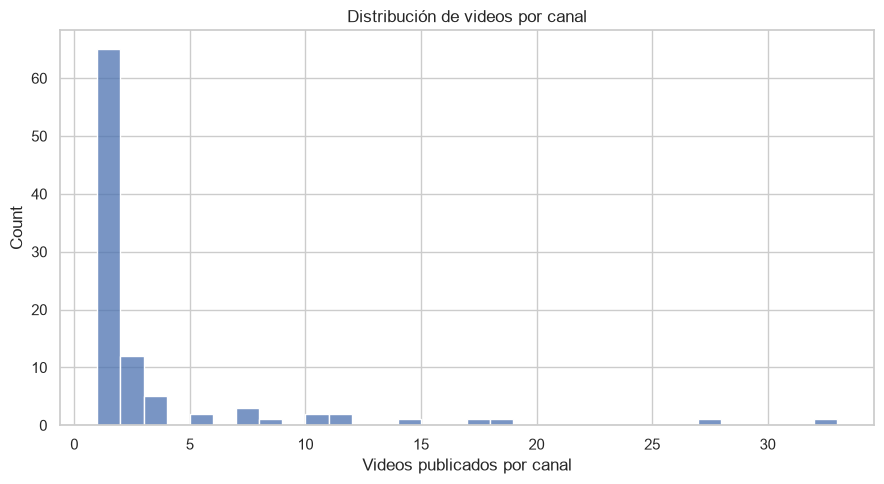

In [23]:
videos_por_canal = videos.groupby("channel_id").size().rename("n_videos")
print("Videos por canal — resumen:")
print(videos_por_canal.describe())

fig, ax = plt.subplots()
sns.histplot(videos_por_canal, bins=range(1, videos_por_canal.max() + 2), ax=ax, color="#4C72B0")
ax.set_title("Distribución de videos por canal")
ax.set_xlabel("Videos publicados por canal")
plt.tight_layout()
plt.show()

In [24]:
comentarios_por_video = comments.groupby("video_id").size().rename("n_comentarios")
autores_por_video = comments.groupby("video_id")["author_channel_id"].nunique().rename("n_autores_unicos")

tabla_por_video = pd.concat([comentarios_por_video, autores_por_video], axis=1).sort_values(
    "n_comentarios", ascending=False
)
tabla_por_video = tabla_por_video.join(videos.set_index("video_id")[["title", "channel_name", "category"]])
tabla_por_video

,n_comentarios,n_autores_unicos,title,channel_name,category
video_id,,,,,
n8iP75gIpmw,161,128,Qué rico come tu diputado,Quorum,News & Politics
j43HgwYFKfk,50,49,La cooptación de Walter Mazariegos en la USAC,Quorum,News & Politics
6W4u8sGEnGM,45,32,Inician los trabajos de recuperación del Puent...,Gobierno de la República de Guatemala,Entertainment
lj983NWyAQY,25,25,Plan 2032 Ciudad de Guatemala,Municipalidad de Guatemala,News & Politics
PjmxCj-a9Hg,25,19,Conferencia de Prensa del Gobierno de Guatemal...,Gobierno de la República de Guatemala,Entertainment
OkXlHx0hx-8,25,18,EE.UU. envía a mexicanos deportados a Guatemal...,Noticias Telemundo,News & Politics
yLZS3JiEBg8,16,16,Arroz con pollo a la MONOPOLIO,Quorum,News & Politics
06mFNPU0aB8,14,13,Capturan a presuntos delincuentes disfrazados ...,Noti7,News & Politics
ndAZjHqzzT8,12,10,Internet: escoger el menos malo,Quorum,News & Politics


In [25]:
print("Comentarios por video (solo videos con >=1 comentario):")
print(comentarios_por_video.describe())
print()
print("Autores únicos por video (solo videos con >=1 comentario):")
print(autores_por_video.describe())

Comentarios por video (solo videos con >=1 comentario):
count     19.000000
mean      21.368421
std       36.824223
min        1.000000
25%        2.500000
50%        7.000000
75%       25.000000
max      161.000000
Name: n_comentarios, dtype: float64

Autores únicos por video (solo videos con >=1 comentario):
count     19.000000
mean      18.052632
std       29.457076
min        1.000000
25%        2.500000
50%        7.000000
75%       18.500000
max      128.000000
Name: n_autores_unicos, dtype: float64


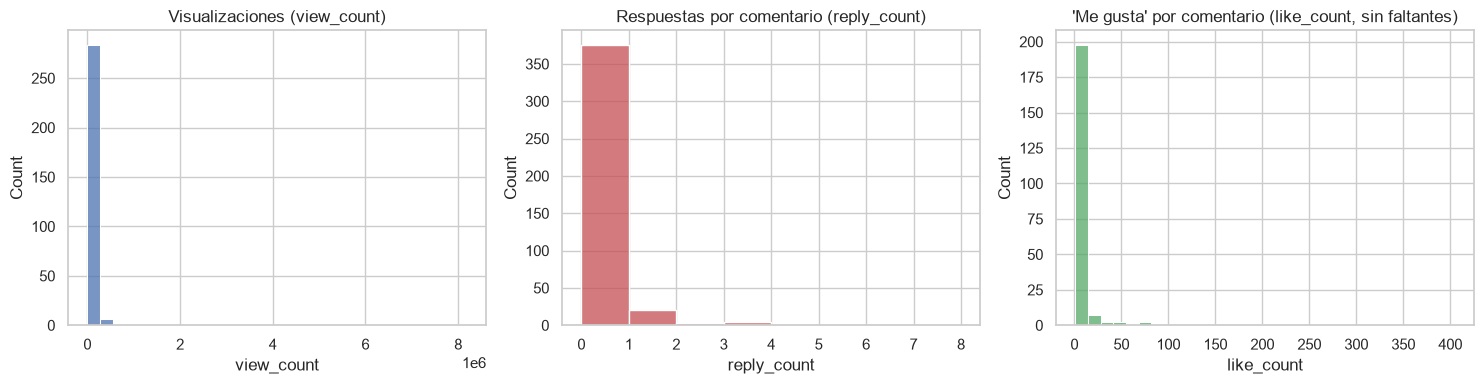

count    2.930000e+02
mean     6.043009e+04
std      5.157983e+05
min      2.000000e+00
25%      2.150000e+02
50%      1.175000e+03
75%      7.465000e+03
max      8.190449e+06
Name: view_count, dtype: float64

count    406.000000
mean       0.125616
std        0.580748
min        0.000000
25%        0.000000
50%        0.000000
75%        0.000000
max        7.000000
Name: reply_count, dtype: float64

count        217.0
mean     10.714286
std      41.340405
min            1.0
25%            1.0
50%            2.0
75%            4.0
max          405.0
Name: like_count, dtype: Float64


In [26]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.histplot(videos["view_count"], bins=30, ax=axes[0], color="#4C72B0")
axes[0].set_title("Visualizaciones (view_count)")

sns.histplot(comments["reply_count"], bins=range(0, comments["reply_count"].max() + 2), ax=axes[1], color="#C44E52")
axes[1].set_title("Respuestas por comentario (reply_count)")

sns.histplot(comments["like_count"].dropna(), bins=30, ax=axes[2], color="#55A868")
axes[2].set_title("'Me gusta' por comentario (like_count, sin faltantes)")
plt.tight_layout()
plt.show()

print(videos["view_count"].describe())
print()
print(comments["reply_count"].describe())
print()
print(comments["like_count"].describe())

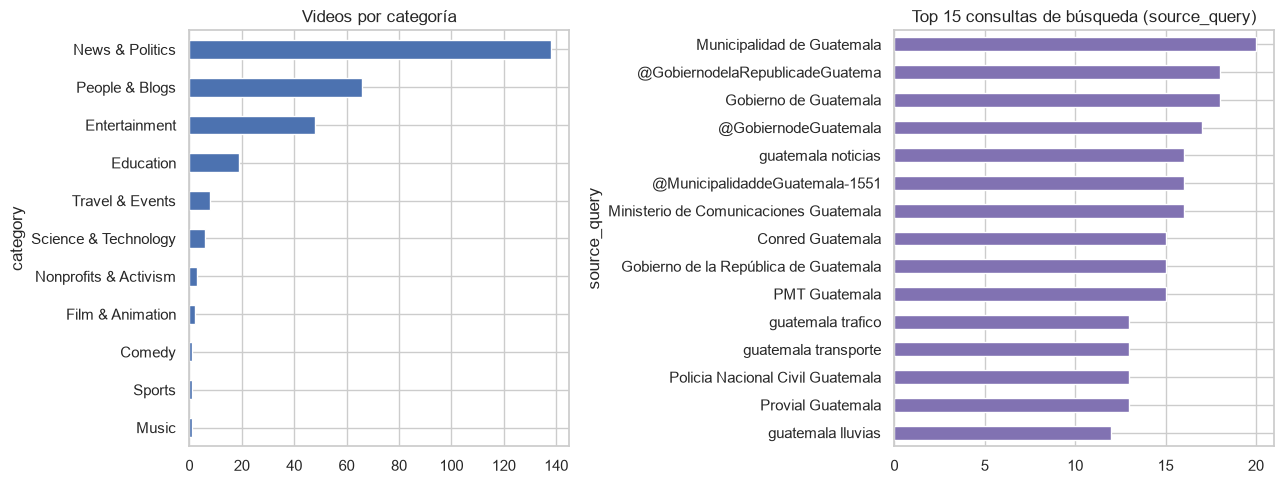

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

videos["category"].value_counts().plot(kind="barh", ax=axes[0], color="#4C72B0")
axes[0].set_title("Videos por categoría")
axes[0].invert_yaxis()

videos["source_query"].value_counts().head(15).plot(kind="barh", ax=axes[1], color="#8172B2")
axes[1].set_title("Top 15 consultas de búsqueda (source_query)")
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

In [28]:
todos_los_hashtags = comments["hashtags"].explode().dropna()
todos_los_hashtags = todos_los_hashtags[todos_los_hashtags.str.len() > 0]

print(f"Comentarios con al menos un hashtag: {(comments['hashtags'].str.len() > 0).sum()} de {len(comments)}")
print(f"Hashtags distintos: {todos_los_hashtags.nunique()}")
todos_los_hashtags.str.lower().value_counts().head(15)

Comentarios con al menos un hashtag: 1 de 406
Hashtags distintos: 1


hashtags
ineptobran    1
Name: count, dtype: int64

In [29]:
def tokens_validos(texto_limpio):
    return [t for t in texto_limpio.split() if len(t) > 2]

todos_los_tokens = comments["texto_limpio"].apply(tokens_validos).sum()
freq_palabras = Counter(todos_los_tokens)

print("Palabras distintas tras limpieza:", len(freq_palabras))
pd.Series(dict(freq_palabras.most_common(20)), name="frecuencia").to_frame()

Palabras distintas tras limpieza: 1935


,frecuencia
cara,83
hacer,72
Guatemala,71
pueblo,56
diputado,51
pagar,38
poder,36
llorar,36
país,35
presidente,35


In [30]:
def bigramas(tokens):
    return list(zip(tokens, islice(tokens, 1, None)))

todos_los_bigramas = comments["texto_limpio"].apply(lambda t: bigramas(tokens_validos(t))).sum()
freq_bigramas = Counter(todos_los_bigramas)

top_bigramas = pd.Series(
    {f"{a} {b}": v for (a, b), v in freq_bigramas.most_common(15)}, name="frecuencia"
).to_frame()
top_bigramas

,frecuencia
cara llorar,36
llorar risa,29
risa cara,22
bandera Guatemala,19
mano aplaudir,19
cañón confeti,15
hacia arriba,15
pulgar hacia,14
Guatemala bandera,12
presidente bernardo,9


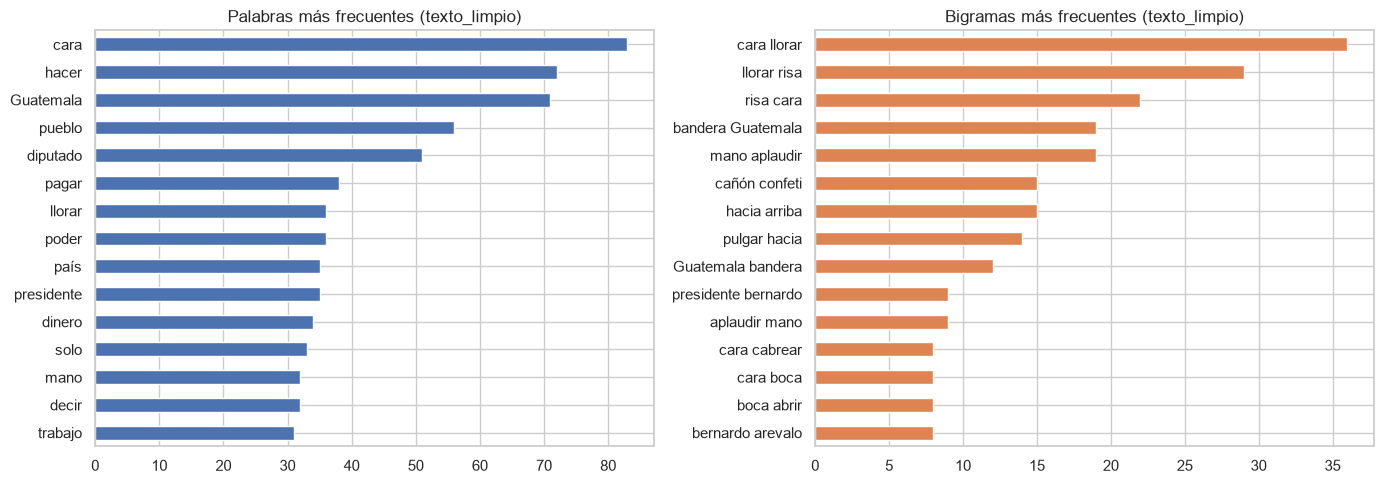

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

pd.Series(dict(freq_palabras.most_common(15))).sort_values().plot(
    kind="barh", ax=axes[0], color="#4C72B0"
)
axes[0].set_title("Palabras más frecuentes (texto_limpio)")

top_bigramas.iloc[::-1]["frecuencia"].plot(kind="barh", ax=axes[1], color="#DD8452")
axes[1].set_title("Bigramas más frecuentes (texto_limpio)")

plt.tight_layout()
plt.show()

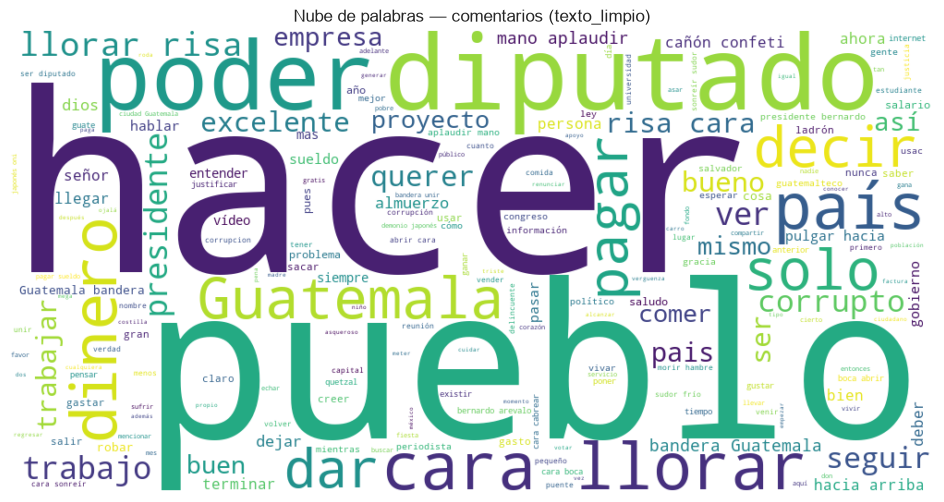

In [32]:
from wordcloud import WordCloud

texto_para_nube = " ".join(todos_los_tokens)
nube = WordCloud(width=1000, height=500, background_color="white", colormap="viridis").generate(texto_para_nube)

plt.figure(figsize=(12, 6))
plt.imshow(nube, interpolation="bilinear")
plt.axis("off")
plt.title("Nube de palabras — comentarios (texto_limpio)")
plt.show()

La nube de palabras es únicamente ilustrativa: los gráficos de barras
anteriores son los que permiten comparar frecuencias de forma cuantitativa
(la nube distorsiona la percepción de proporciones por el tamaño de fuente y
el layout).

### 3.2 Concentración de la participación

In [33]:
def curva_concentracion(conteos, nombre):
    conteos_ordenados = conteos.sort_values(ascending=False)
    acumulado = conteos_ordenados.cumsum() / conteos_ordenados.sum()
    return acumulado.reset_index(drop=True)

comentarios_por_canal = comments.groupby("channel_id").size()

conc_video = curva_concentracion(comentarios_por_video, "video")
conc_canal = curva_concentracion(comentarios_por_canal, "canal")

for n in [1, 3, 5, 10]:
    print(f"Top {n} video(s) concentra(n) el "
          f"{conc_video.iloc[min(n, len(conc_video)) - 1]:.1%} de los comentarios")
print()
for n in [1, 3, 5, 10]:
    print(f"Top {n} canal(es) concentra(n) el "
          f"{conc_canal.iloc[min(n, len(conc_canal)) - 1]:.1%} de los comentarios")

Top 1 video(s) concentra(n) el 39.7% de los comentarios
Top 3 video(s) concentra(n) el 63.1% de los comentarios
Top 5 video(s) concentra(n) el 75.4% de los comentarios
Top 10 video(s) concentra(n) el 93.6% de los comentarios

Top 1 canal(es) concentra(n) el 63.1% de los comentarios
Top 3 canal(es) concentra(n) el 86.5% de los comentarios
Top 5 canal(es) concentra(n) el 96.1% de los comentarios
Top 10 canal(es) concentra(n) el 100.0% de los comentarios


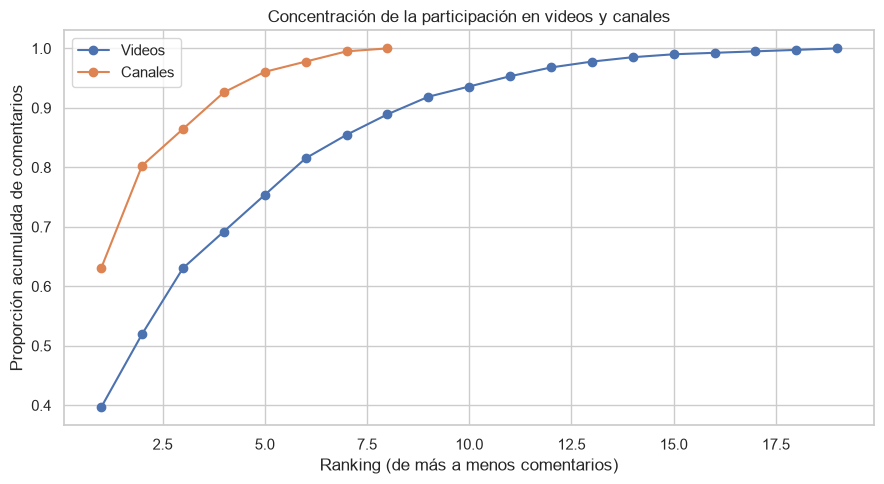

In [34]:
fig, ax = plt.subplots()
ax.plot(range(1, len(conc_video) + 1), conc_video, marker="o", label="Videos")
ax.plot(range(1, len(conc_canal) + 1), conc_canal, marker="o", label="Canales")
ax.set_xlabel("Ranking (de más a menos comentarios)")
ax.set_ylabel("Proporción acumulada de comentarios")
ax.set_title("Concentración de la participación en videos y canales")
ax.legend()
plt.tight_layout()
plt.show()

La participación está fuertemente concentrada: los **19 videos con
comentarios** ya son una fracción mínima (6.5 %) de los 293 videos
recolectados, y dentro de esos 19, unos pocos acumulan la mayoría de los
comentarios (ver tabla de la sección 3.1). Esta concentración limita
cualquier generalización sobre "la conversación en YouTube" a partir de esta
muestra — en realidad se está observando la conversación en un puñado de
videos puntuales.

### 3.3 Popularidad vs. participación

Correlación de Spearman entre view_count y n_comentarios (videos con comentarios): 0.81


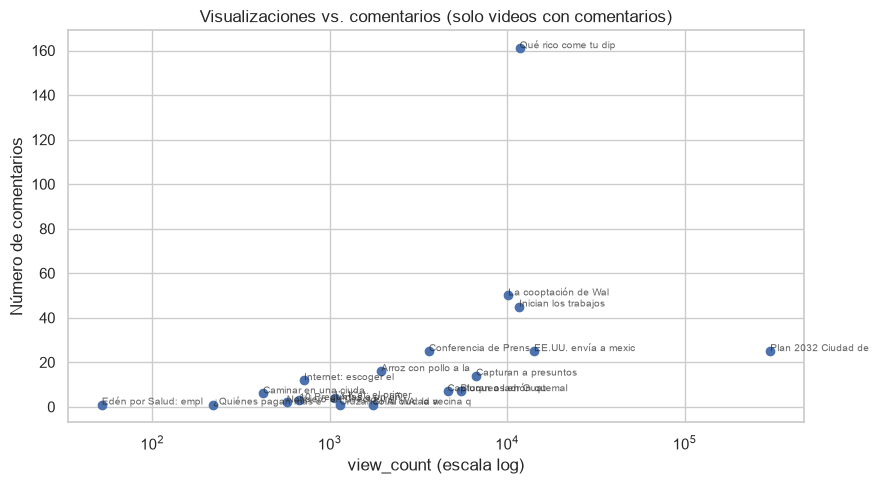

In [35]:
comparacion = tabla_por_video.join(videos.set_index("video_id")[["view_count"]])
comparacion = comparacion[["view_count", "n_comentarios", "n_autores_unicos", "title"]]

correlacion = comparacion[["view_count", "n_comentarios"]].corr(method="spearman").iloc[0, 1]
print(f"Correlación de Spearman entre view_count y n_comentarios (videos con comentarios): {correlacion:.2f}")

fig, ax = plt.subplots()
ax.scatter(comparacion["view_count"], comparacion["n_comentarios"])
for vid, row in comparacion.iterrows():
    ax.annotate(row["title"][:20], (row["view_count"], row["n_comentarios"]), fontsize=7, alpha=0.7)
ax.set_xscale("log")
ax.set_xlabel("view_count (escala log)")
ax.set_ylabel("Número de comentarios")
ax.set_title("Visualizaciones vs. comentarios (solo videos con comentarios)")
plt.tight_layout()
plt.show()

`view_count` y `n_comentarios` no están fuertemente asociados en esta
muestra: hay videos con muchas visualizaciones y pocos comentarios, y
viceversa. Ambos conteos tienen limitaciones importantes: `view_count` es un
conteo acumulado hasta el momento de la recolección (no distingue
visualizaciones recientes de antiguas ni visualizaciones repetidas de un
mismo usuario) y `n_comentarios` depende de que YouTube haya expuesto y el
scraper haya logrado capturar los comentarios de ese video específico — no
todos los videos fueron sometidos al mismo esfuerzo de recolección de
comentarios (recordar que solo 19 de 293 videos tienen comentarios en el
dataset).

### 3.4 Visualizaciones adicionales

Las visualizaciones principales ya se presentaron junto con cada hallazgo
(3.1–3.3): histogramas de videos por canal, visualizaciones, respuestas y
"me gusta"; barras de categorías, consultas y hashtags; barras de palabras y
bigramas frecuentes; nube de palabras; curva de concentración; y dispersión
de popularidad vs. participación.

### 3.5 Preguntas obligatorias

**¿Qué videos y canales concentran la mayor participación observada?**
Los videos con más comentarios son los que encabezan `tabla_por_video`
(sección 3.1); a nivel de canal, la curva de concentración (3.2) muestra que
un número reducido de canales acumula la mayoría de los 406 comentarios. Es
importante notar que esta "participación" está condicionada por qué videos
fueron seleccionados para recolectar comentarios, no solo por qué videos
generan más conversación en general.

**¿Existen audiencias compartidas entre videos, canales o temas?**
Sí, de forma limitada: 9 de los 332 autores (`author_channel_id`) comentaron
en más de un video de los 19 disponibles. Es una señal débil pero real de
audiencia compartida; se cuantifica formalmente con la red bipartita del
ejercicio 4 y sus proyecciones en el documento final.

**¿Qué autores funcionan como puentes entre contenidos que de otra forma
permanecerían separados?**
Esta pregunta requiere el análisis de centralidad e intermediación sobre la
red construida en el ejercicio 4 (ver ejercicio 8), que se desarrolla en el
documento final. Con la información exploratoria disponible aquí solo puede
adelantarse que los candidatos son, como máximo, esos mismos 9 autores que
comentan en más de un video.

**¿Qué temas y sentimientos caracterizan a las principales comunidades de
participación?**
Requiere detección de comunidades (ejercicio 7) y análisis de sentimiento
(ejercicio 9), ambos pendientes para el documento final. La sección 3.1
adelanta los temas más frecuentes a nivel global (palabras, bigramas y
hashtags más comunes en los comentarios).

**¿La visibilidad medida mediante visualizaciones coincide con la
participación observada?**
No necesariamente: la correlación de Spearman calculada en 3.3 entre
`view_count` y `n_comentarios` es débil, y el diagrama de dispersión muestra
casos de alta visibilidad con poca conversación y viceversa.

**¿Qué conclusiones están limitadas por el procedimiento de recolección y la
cobertura de los datos?**
Toda conclusión sobre "participación en YouTube" está limitada porque: (a)
solo el 6.5 % de los videos tiene comentarios recolectados; (b) la selección
de videos depende de `source_query`/`source_group`, es decir, de consultas de
búsqueda específicas y no de un muestreo aleatorio de YouTube; (c) las
fechas son relativas al momento de recolección, no fechas absolutas
comparables entre sí sin más información; y (d) los conteos (`view_count`,
`like_count`, `reply_count`) reflejan un instante fijo, no la evolución de la
audiencia.

### 3.6 Preguntas adicionales

In [36]:
# Pregunta adicional 1: ¿qué categorías editoriales concentran más comentarios,
# relativo a cuántos videos tienen en el dataset?
cat_videos = videos["category"].value_counts().rename("n_videos")
cat_comentarios = (
    comments.merge(videos[["video_id", "category"]], on="video_id")
    .groupby("category")
    .size()
    .rename("n_comentarios")
)
tabla_categoria = pd.concat([cat_videos, cat_comentarios], axis=1).fillna(0)
tabla_categoria["comentarios_por_video"] = (
    tabla_categoria["n_comentarios"] / tabla_categoria["n_videos"]
).round(2)
tabla_categoria.sort_values("comentarios_por_video", ascending=False)

,n_videos,n_comentarios,comentarios_por_video
category,,,
News & Politics,138,335.0,2.43
Entertainment,48,70.0,1.46
Nonprofits & Activism,3,1.0,0.33
People & Blogs,66,0.0,0.00
Education,19,0.0,0.00
Travel & Events,8,0.0,0.00
Science & Technology,6,0.0,0.00
Film & Animation,2,0.0,0.00
Comedy,1,0.0,0.00


**Respuesta:** `News & Politics` concentra la mayoría de los videos (138) y
también la mayoría de los comentarios en términos absolutos, pero al
normalizar por número de videos, otras categorías con pocos videos pueden
tener una tasa de comentarios por video más alta — evidencia de que el
volumen de comentarios no es homogéneo entre categorías, sino que depende de
qué videos puntuales de cada categoría fueron efectivamente comentados.

In [37]:
# Pregunta adicional 2: ¿los autores que comentan más de una vez lo hacen en el
# mismo video (varios comentarios en un solo video) o en videos distintos?
comentarios_por_autor = comments.groupby("author_channel_id").size().rename("n_comentarios")
videos_por_autor = comments.groupby("author_channel_id")["video_id"].nunique().rename("n_videos_distintos")

autores_multi = pd.concat([comentarios_por_autor, videos_por_autor], axis=1)
autores_multi = autores_multi[autores_multi["n_comentarios"] > 1]

print(f"Autores con más de 1 comentario: {len(autores_multi)} de {comments['author_channel_id'].nunique()}")
print(f"  - de esos, comentan siempre en el mismo video: "
      f"{(autores_multi['n_videos_distintos'] == 1).sum()}")
print(f"  - de esos, comentan en más de un video distinto: "
      f"{(autores_multi['n_videos_distintos'] > 1).sum()}")
autores_multi.sort_values("n_comentarios", ascending=False).head(10)

Autores con más de 1 comentario: 46 de 332
  - de esos, comentan siempre en el mismo video: 37
  - de esos, comentan en más de un video distinto: 9


,n_comentarios,n_videos_distintos
author_channel_id,,
UCyJhqmMbsvjpoarBBStA2kg,6,1
UCi2KiZq63sRq8Mfbcp-MelQ,6,1
UC5H8ASmMC9WrURmzeB4ySog,5,1
UCV3fr-YOixFKCZBbJP1-X4w,5,1
UCvcu1kR8xMYy_I1Ty-2mV2Q,4,3
UC9vMq1YF-e7C-VO0SHkbUTA,4,1
UCNIeXbV_mEwpa412h1aqUWw,3,1
UCg3eIfd7BrsLEqS0BLkftHA,3,1
UCh5ESQvtzyHDhCA7XyekCFA,3,1


**Respuesta:** la mayoría de los autores que comentan más de una vez lo hacen
**dentro del mismo video** (varios comentarios en un solo hilo), no
distribuidos entre videos distintos. Esto anticipa que la proyección
autor-autor del ejercicio 5 tendrá relativamente pocos autores puente reales
entre videos, y que buena parte del peso de las aristas autor-video vendrá de
usuarios muy activos en un único video, no de audiencias que efectivamente
migran entre contenidos.

In [38]:
# Pregunta adicional 3: ¿el uso de hashtags en los comentarios se concentra en
# videos o autores particulares, o está disperso?
comentarios_con_hashtag = comments[comments["hashtags"].str.len() > 0]
print(f"Comentarios con hashtag: {len(comentarios_con_hashtag)} de {len(comments)} "
      f"({len(comentarios_con_hashtag) / len(comments):.1%})")
print()
print("Distribución por video:")
print(comentarios_con_hashtag.groupby("video_id").size().sort_values(ascending=False))

Comentarios con hashtag: 1 de 406 (0.2%)

Distribución por video:
video_id
WIUZtitfLRw    1
dtype: int64


**Respuesta:** el uso de hashtags dentro de los comentarios (a diferencia de
las palabras clave del video) es marginal en esta muestra; cuando aparece,
se concentra en muy pocos videos/autores en lugar de estar disperso
uniformemente, lo que sugiere que es una práctica puntual de ciertos
usuarios y no una convención generalizada de la conversación observada.

## 4. Construcción de la red bipartita autor–video

### 4.1–4.2 Definición de nodos, aristas y peso

- **Conjunto de nodos "autor"**: `author_channel_id` de `youtube_comments.csv`.
- **Conjunto de nodos "video"**: `video_id` de `youtube_videos.csv` — se
  incluyen únicamente los videos que efectivamente recibieron al menos un
  comentario, ya que solo esos pueden tener una arista.
- **Arista**: no dirigida, entre un autor y un video, que existe si ese autor
  publicó al menos un comentario en ese video.
- **Peso de la arista**: número de comentarios que ese autor publicó en ese
  video específico (puede ser mayor a 1).

In [39]:
aristas = (
    comments.groupby(["author_channel_id", "video_id"])
    .size()
    .rename("peso")
    .reset_index()
)
print(f"Aristas (pares autor-video únicos): {len(aristas)}  (de {len(comments)} comentarios)")
print(f"Aristas con peso > 1: {(aristas['peso'] > 1).sum()}")
aristas.sort_values("peso", ascending=False).head(10)

Aristas (pares autor-video únicos): 343  (de 406 comentarios)
Aristas con peso > 1: 40


,author_channel_id,video_id,peso
244,UCi2KiZq63sRq8Mfbcp-MelQ,OkXlHx0hx-8,6
331,UCyJhqmMbsvjpoarBBStA2kg,6W4u8sGEnGM,6
33,UC5H8ASmMC9WrURmzeB4ySog,n8iP75gIpmw,5
165,UCV3fr-YOixFKCZBbJP1-X4w,6W4u8sGEnGM,5
57,UC9vMq1YF-e7C-VO0SHkbUTA,n8iP75gIpmw,4
25,UC3XTwHxygNCgjndsg-UiCQA,n8iP75gIpmw,3
46,UC72gBAtyb_VXQlYDcFrh6oQ,n8iP75gIpmw,3
85,UCFjudnPLoaSL1BaRuLahyHg,n8iP75gIpmw,3
120,UCNIeXbV_mEwpa412h1aqUWw,PjmxCj-a9Hg,3
226,UCg3eIfd7BrsLEqS0BLkftHA,PjmxCj-a9Hg,3


### 4.3 Tabla de nodos y tabla de aristas

In [40]:
videos_con_datos = videos.set_index("video_id").loc[aristas["video_id"].unique()]

nodos_video = pd.DataFrame({
    "node_id": videos_con_datos.index,
    "tipo": "video",
    "etiqueta": videos_con_datos["title"],
    "channel_id": videos_con_datos["channel_id"],
    "channel_name": videos_con_datos["channel_name"],
    "category": videos_con_datos["category"],
    "view_count": videos_con_datos["view_count"],
}).reset_index(drop=True)

autores_activos = aristas["author_channel_id"].unique()
nombres_autores = comments.drop_duplicates("author_channel_id").set_index("author_channel_id")["author_name"]

nodos_autor = pd.DataFrame({
    "node_id": autores_activos,
    "tipo": "autor",
    "etiqueta": nombres_autores.loc[autores_activos].values,
    "n_comentarios_total": comentarios_por_autor.loc[autores_activos].values,
    "n_videos_distintos": videos_por_autor.loc[autores_activos].values,
})

tabla_nodos = pd.concat([nodos_video, nodos_autor], ignore_index=True)
tabla_aristas = aristas.rename(columns={"author_channel_id": "source", "video_id": "target", "peso": "weight"})

print(f"Tabla de nodos: {len(tabla_nodos)} filas ({(tabla_nodos['tipo'] == 'autor').sum()} autores, "
      f"{(tabla_nodos['tipo'] == 'video').sum()} videos)")
print(f"Tabla de aristas: {len(tabla_aristas)} filas")

tabla_nodos.to_csv("data/red_bipartita_nodos.csv", index=False)
tabla_aristas.to_csv("data/red_bipartita_aristas.csv", index=False)

tabla_nodos.head()

Tabla de nodos: 351 filas (332 autores, 19 videos)
Tabla de aristas: 343 filas


,node_id,tipo,etiqueta,channel_id,channel_name,category,view_count,n_comentarios_total,n_videos_distintos
0,6W4u8sGEnGM,video,Inician los trabajos de recuperación del Puent...,UC-ZtFBHzgkYFh7whZkuR_Ag,Gobierno de la República de Guatemala,Entertainment,11670.0,NaN,NaN
1,OkXlHx0hx-8,video,EE.UU. envía a mexicanos deportados a Guatemal...,UCRwA1NUcUnwsly35ikGhp0A,Noticias Telemundo,News & Politics,14200.0,NaN,NaN
2,j43HgwYFKfk,video,La cooptación de Walter Mazariegos en la USAC,UCE4rsXcgDb6e1-a9iTbWzfg,Quorum,News & Politics,10156.0,NaN,NaN
3,n8iP75gIpmw,video,Qué rico come tu diputado,UCE4rsXcgDb6e1-a9iTbWzfg,Quorum,News & Politics,11775.0,NaN,NaN
4,b_Hkrkl3adA,video,Bloqueos en Guatemala este 31 de agosto por al...,UCEepOY2svuxbsJ-zsAPT9Fg,PrensaLibreOficial,News & Politics,5469.0,NaN,NaN


In [41]:
tabla_aristas.head()

,source,target,weight
0,UC-HeUTT6_g-VoiWds2a4H-w,6W4u8sGEnGM,1
1,UC-Iul5tDYH_oiAMXQH-KaaQ,6W4u8sGEnGM,1
2,UC-QOpE7GOxlXcHZ8b7HbQKA,OkXlHx0hx-8,2
3,UC-fiZBS5Gp1eCJd9ucgWnCg,j43HgwYFKfk,1
4,UC-hfX8J5JPJ-dfuakzegMLA,n8iP75gIpmw,1


### 4.4 Visualización de la red completa

In [42]:
B = nx.Graph()

for _, fila in nodos_video.iterrows():
    B.add_node(fila["node_id"], bipartite="video", etiqueta=fila["etiqueta"], category=fila["category"])

for _, fila in nodos_autor.iterrows():
    B.add_node(fila["node_id"], bipartite="autor", etiqueta=fila["etiqueta"])

for _, fila in tabla_aristas.iterrows():
    B.add_edge(fila["source"], fila["target"], weight=fila["weight"])

print(f"Nodos: {B.number_of_nodes()} | Aristas: {B.number_of_edges()}")

Nodos: 351 | Aristas: 343


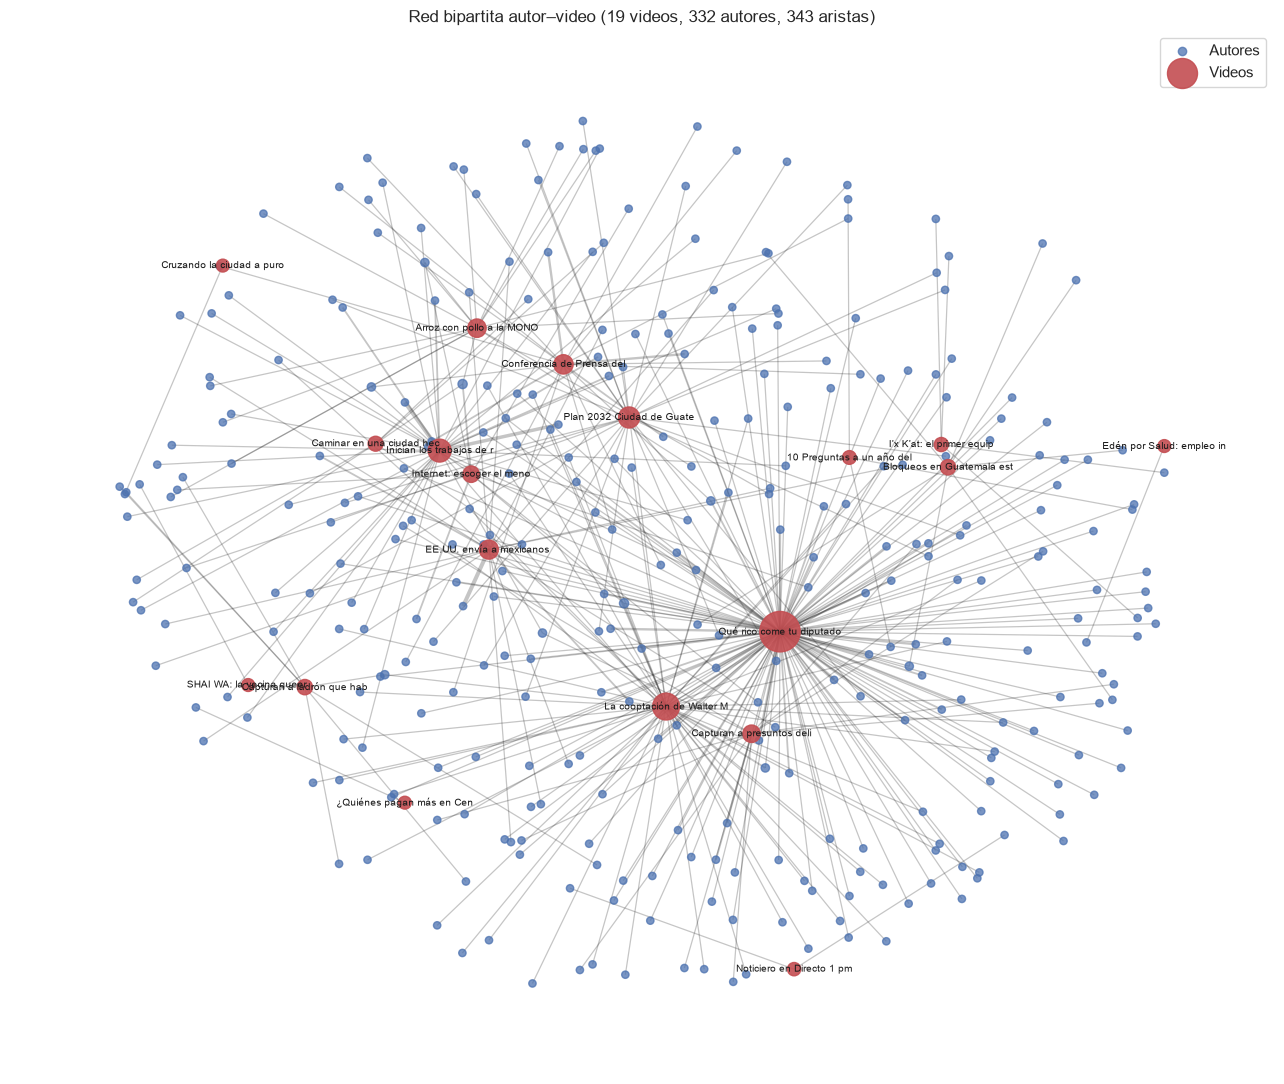

In [43]:
pos = nx.spring_layout(B, k=0.35, seed=RANDOM_STATE, weight="weight")

nodos_video_id = [n for n, d in B.nodes(data=True) if d["bipartite"] == "video"]
nodos_autor_id = [n for n, d in B.nodes(data=True) if d["bipartite"] == "autor"]

grado = dict(B.degree())
pesos_aristas = [B[u][v]["weight"] for u, v in B.edges()]

fig, ax = plt.subplots(figsize=(13, 11))

nx.draw_networkx_edges(B, pos, alpha=0.25, width=[0.5 + 0.4 * w for w in pesos_aristas], ax=ax)

nx.draw_networkx_nodes(
    B, pos, nodelist=nodos_autor_id,
    node_size=[20 + 8 * grado[n] for n in nodos_autor_id],
    node_color="#4C72B0", alpha=0.75, label="Autores", ax=ax,
)
nx.draw_networkx_nodes(
    B, pos, nodelist=nodos_video_id,
    node_size=[80 + 6 * grado[n] for n in nodos_video_id],
    node_color="#C44E52", alpha=0.9, label="Videos", ax=ax,
)

etiquetas_video = {n: B.nodes[n]["etiqueta"][:25] for n in nodos_video_id}
nx.draw_networkx_labels(B, pos, labels=etiquetas_video, font_size=7, ax=ax)

ax.set_title("Red bipartita autor–video (19 videos, 332 autores, 343 aristas)")
ax.legend(scatterpoints=1)
ax.axis("off")
plt.tight_layout()
plt.savefig("data/red_bipartita_autor_video.png", dpi=150)
plt.show()

El diseño en `spring_layout` no elimina ningún nodo ni arista: se observan
19 "estrellas" (un video central rodeado de sus autores), algunas de ellas
unidas entre sí por los pocos autores que comentaron en más de un video —
esos autores compartidos son los únicos puntos de conexión entre videos que,
de otro modo, formarían componentes completamente separados.

### 4.5 Interpretación precisa de la arista

Una arista en esta red bipartita significa **únicamente** que un autor
publicó al menos un comentario principal en un video determinado; el peso
indica **cuántos** comentarios publicó ese autor en ese video. Esta arista:

- **No implica** que el autor haya recibido respuesta de otros usuarios o del
  canal.
- **No implica** relación, conversación directa o interacción entre dos
  autores del mismo video (eso se modela, con sus propias limitaciones, en la
  proyección autor-autor del ejercicio 5, y no debe confundirse con esta red
  bipartita).
- **No implica** aprobación, respaldo ni ningún tipo de vínculo afectivo con
  el contenido del video ni con el canal que lo publicó.
- Tal como advierte el enunciado del laboratorio, `reply_count` (número de
  respuestas que recibió un comentario) **no se usa** para construir aristas,
  porque no identifica quién respondió.

## 5. Proyecciones de la red

### 5.1 Proyección autor–autor

Dos autores se conectan si comentaron en el mismo video; el peso es el
número de videos que ambos comentaron en común (no el número de comentarios).
Se construye con la proyección ponderada bipartita de `networkx`, que cuenta
vecinos compartidos automáticamente.

In [44]:
AA = nx.bipartite.weighted_projected_graph(B, nodos_autor_id)
print(f"Proyección autor-autor: {AA.number_of_nodes()} nodos, {AA.number_of_edges()} aristas")
print("Distribución de pesos (videos compartidos):")
print(pd.Series([d["weight"] for _, _, d in AA.edges(data=True)]).value_counts().sort_index())

Proyección autor-autor: 332 nodos, 10732 aristas
Distribución de pesos (videos compartidos):
1    10730
2        2
Name: count, dtype: int64


La proyección autor–autor concentra casi 10 000 aristas a pesar de tener
solo 332 nodos: esto **no** significa que existan miles de relaciones
sociales reales, sino que es el efecto matemático esperado de proyectar una
red bipartita en la que un solo video puede tener docenas de autores — cada
video con *n* autores agrega hasta *n*·(*n*−1)/2 aristas de peso 1 entre
ellos (todos "co-comentaron" ese video), sin que eso implique que se leyeron
o interactuaron entre sí. Es la advertencia central del enunciado sobre no
sobre-interpretar la co-participación como conversación o vínculo directo.

### 5.2 Proyección video–video

Dos videos se conectan si comparten al menos un autor; el peso es el número
de autores distintos que comentaron en ambos.

In [45]:
VV = nx.bipartite.weighted_projected_graph(B, nodos_video_id)
print(f"Proyección video-video: {VV.number_of_nodes()} nodos, {VV.number_of_edges()} aristas")

tabla_vv = pd.DataFrame(
    [(u, v, d["weight"]) for u, v, d in VV.edges(data=True)],
    columns=["video_a", "video_b", "autores_compartidos"],
).sort_values("autores_compartidos", ascending=False)
tabla_vv["titulo_a"] = tabla_vv["video_a"].map(videos.set_index("video_id")["title"])
tabla_vv["titulo_b"] = tabla_vv["video_b"].map(videos.set_index("video_id")["title"])
tabla_vv

Proyección video-video: 19 nodos, 11 aristas


,video_a,video_b,autores_compartidos,titulo_a,titulo_b
3,j43HgwYFKfk,n8iP75gIpmw,2,La cooptación de Walter Mazariegos en la USAC,Qué rico come tu diputado
8,ndAZjHqzzT8,yLZS3JiEBg8,2,Internet: escoger el menos malo,Arroz con pollo a la MONOPOLIO
0,6W4u8sGEnGM,06mFNPU0aB8,1,Inician los trabajos de recuperación del Puent...,Capturan a presuntos delincuentes disfrazados ...
2,j43HgwYFKfk,ndAZjHqzzT8,1,La cooptación de Walter Mazariegos en la USAC,Internet: escoger el menos malo
1,6W4u8sGEnGM,PjmxCj-a9Hg,1,Inician los trabajos de recuperación del Puent...,Conferencia de Prensa del Gobierno de Guatemal...
5,n8iP75gIpmw,PjmxCj-a9Hg,1,Qué rico come tu diputado,Conferencia de Prensa del Gobierno de Guatemal...
4,j43HgwYFKfk,is3Mk5oC19g,1,La cooptación de Walter Mazariegos en la USAC,Capturan a ladrón que había quedado grabado mi...
6,n8iP75gIpmw,b_Hkrkl3adA,1,Qué rico come tu diputado,Bloqueos en Guatemala este 31 de agosto por al...
7,n8iP75gIpmw,ndAZjHqzzT8,1,Qué rico come tu diputado,Internet: escoger el menos malo
9,ndAZjHqzzT8,WIUZtitfLRw,1,Internet: escoger el menos malo,Caminar en una ciudad hecha para carros


### 5.3 Comparación de las proyecciones

| | Autor–autor | Video–video |
|---|---|---|
| Nodos | 332 (todos los autores activos) | 19 (todos los videos con comentarios) |
| Aristas | ≈10 700, muy densa | 11, muy dispersa |
| Qué representa | Co-participación en el mismo video: refleja principalmente la estructura interna de cada hilo de comentarios (casi todo autor que comparte video con otro queda conectado), **no** una red social real entre personas. | Audiencias compartidas entre videos: identifica qué contenidos atrajeron, aunque sea parcialmente, al mismo público comentante — señal más directamente relevante para "temas o audiencias compartidas". |
| Limitación principal | La densidad es en gran parte un artefacto combinatorio de agrupar por video, no evidencia de interacción. | Al haber solo 19 videos y 9 autores que cruzan videos, el número de aristas posibles es pequeño y cualquier patrón debe leerse con cautela estadística. |

En síntesis: la proyección autor–autor es útil para ver la "forma" de la
participación dentro de cada video (cuán grande es su audiencia comentante),
mientras que la proyección video–video es la que realmente aporta evidencia
sobre **audiencias compartidas entre contenidos**, que es una de las
preguntas centrales del laboratorio (3.5).

### 5.4 Visualización de las proyecciones

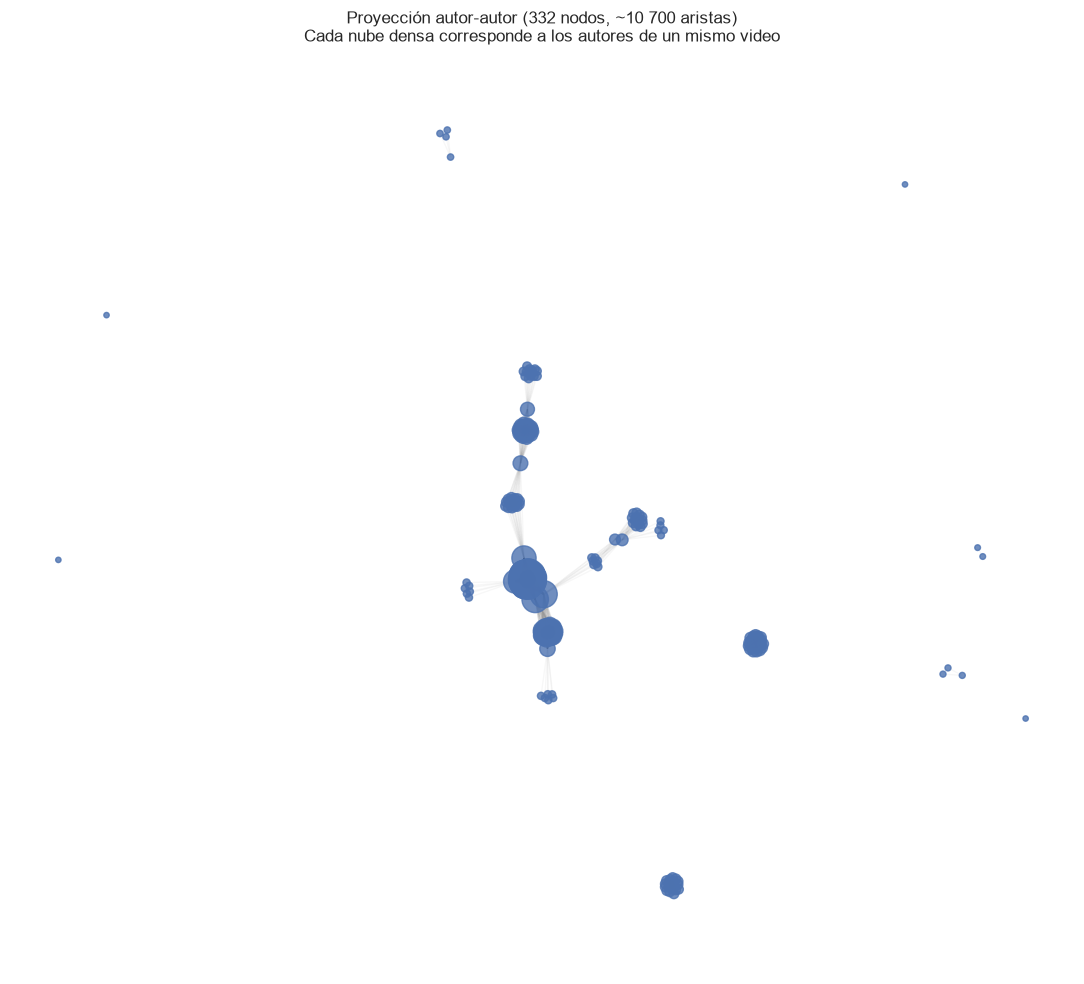

In [46]:
fig, ax = plt.subplots(figsize=(11, 10))
pos_aa = nx.spring_layout(AA, seed=RANDOM_STATE, iterations=50)
grado_aa = dict(AA.degree())

nx.draw_networkx_edges(AA, pos_aa, alpha=0.03, ax=ax)
nx.draw_networkx_nodes(
    AA, pos_aa, node_size=[15 + 2 * grado_aa[n] for n in AA.nodes()],
    node_color="#4C72B0", alpha=0.8, ax=ax,
)
ax.set_title("Proyección autor-autor (332 nodos, ~10 700 aristas)\n"
             "Cada nube densa corresponde a los autores de un mismo video")
ax.axis("off")
plt.tight_layout()
plt.savefig("data/proyeccion_autor_autor.png", dpi=150)
plt.show()

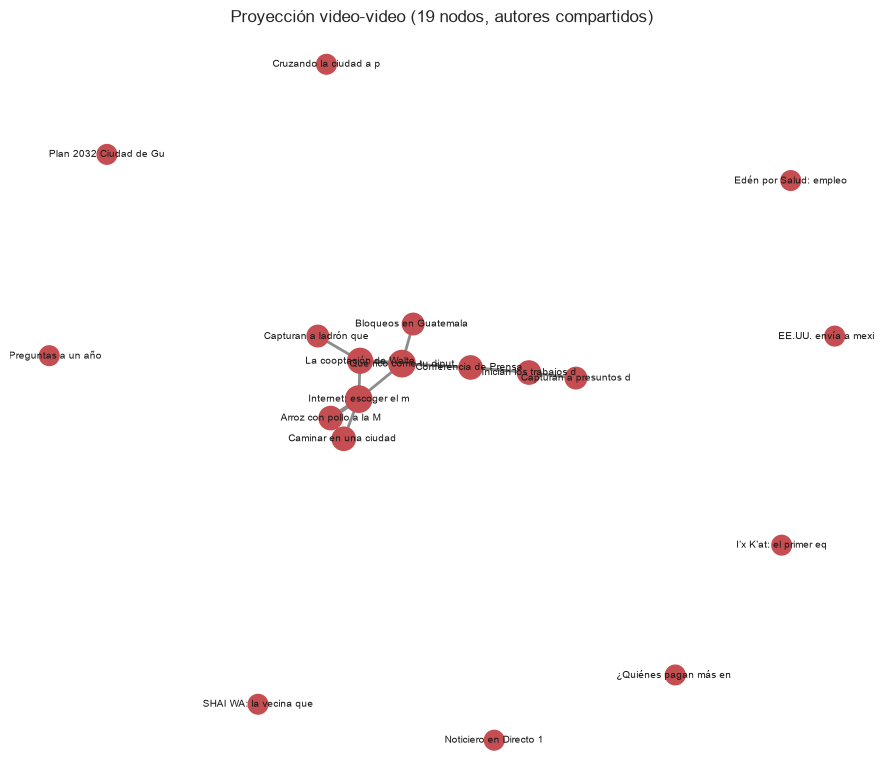

In [47]:
fig, ax = plt.subplots(figsize=(9, 8))
pos_vv = nx.spring_layout(VV, seed=RANDOM_STATE, weight="weight")
pesos_vv = [VV[u][v]["weight"] for u, v in VV.edges()]

nx.draw_networkx_edges(VV, pos_vv, width=[1 + w for w in pesos_vv], alpha=0.5, ax=ax)
nx.draw_networkx_nodes(
    VV, pos_vv, node_size=[200 + 40 * VV.degree(n) for n in VV.nodes()],
    node_color="#C44E52", ax=ax,
)
etiquetas_vv = {n: videos.set_index("video_id").loc[n, "title"][:22] for n in VV.nodes()}
nx.draw_networkx_labels(VV, pos_vv, labels=etiquetas_vv, font_size=7, ax=ax)

ax.set_title("Proyección video-video (19 nodos, autores compartidos)")
ax.axis("off")
plt.tight_layout()
plt.savefig("data/proyeccion_video_video.png", dpi=150)
plt.show()

## 6. Topología y fragmentación

### 6.1 Métricas estructurales

In [48]:
def metricas_topologicas(G, nombre, dirigido=False):
    n, m = G.number_of_nodes(), G.number_of_edges()
    grados = [d for _, d in G.degree()]
    componentes = list(nx.connected_components(G))
    tam_componentes = sorted((len(c) for c in componentes), reverse=True)
    return {
        "red": nombre,
        "nodos": n,
        "aristas": m,
        "densidad": round(nx.density(G), 5),
        "grado_medio": round(np.mean(grados), 3),
        "grado_max": max(grados),
        "num_componentes": len(componentes),
        "tam_componente_mayor": tam_componentes[0],
        "pct_en_componente_mayor": round(tam_componentes[0] / n * 100, 1),
    }

resumen_topologia = pd.DataFrame([
    metricas_topologicas(B, "Bipartita autor-video"),
    metricas_topologicas(AA, "Proyección autor-autor"),
    metricas_topologicas(VV, "Proyección video-video"),
]).set_index("red")
resumen_topologia

,nodos,aristas,densidad,grado_medio,grado_max,num_componentes,tam_componente_mayor,pct_en_componente_mayor
red,,,,,,,,
Bipartita autor-video,351,343,0.00558,1.954,128,10,286,81.5
Proyección autor-autor,332,10732,0.19532,64.651,183,10,276,83.1
Proyección video-video,19,11,0.06433,1.158,4,10,10,52.6


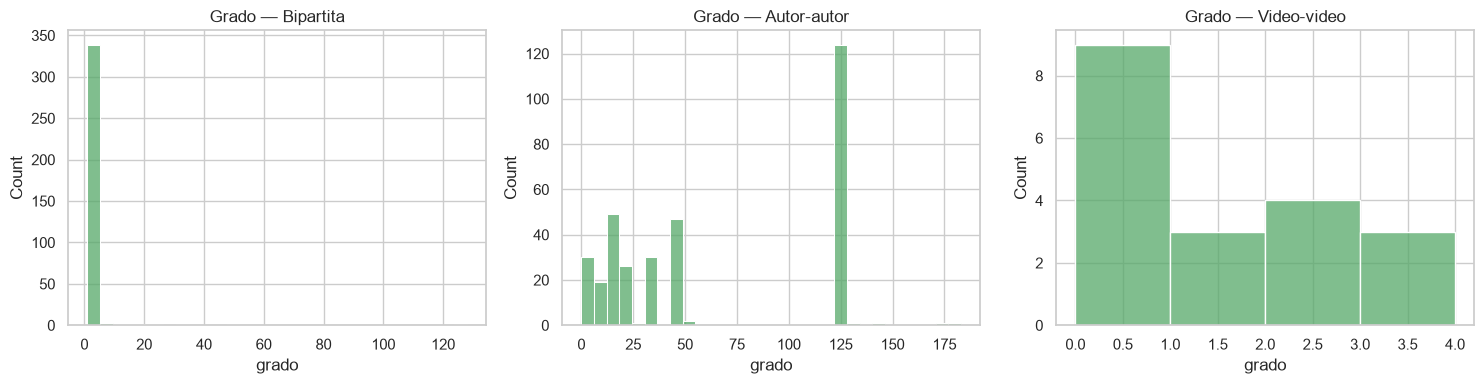

In [49]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, G, nombre in zip(axes, [B, AA, VV], ["Bipartita", "Autor-autor", "Video-video"]):
    grados = [d for _, d in G.degree()]
    sns.histplot(grados, bins=min(30, max(grados)), ax=ax, color="#55A868")
    ax.set_title(f"Grado — {nombre}")
    ax.set_xlabel("grado")
plt.tight_layout()
plt.show()

Las tres redes muestran una distribución de grado muy sesgada a la derecha
(pocos nodos con grado alto, la mayoría con grado bajo), típica de redes de
participación en redes sociales: en la bipartita, la mayoría de los autores
tiene grado 1 (comentó una sola vez, en un solo video) y unos pocos videos
concentran decenas de conexiones; en la proyección autor-autor esto se
traduce en distribuciones de grado muy altas para autores de videos
populosos, simplemente por el tamaño de la "nube" de su video.

### 6.2 Cohesión y transitividad

In [50]:
cohesion = pd.DataFrame({
    "red": ["Bipartita autor-video", "Proyección autor-autor", "Proyección video-video"],
    "transitividad_global": [
        nx.transitivity(B),
        nx.transitivity(AA),
        nx.transitivity(VV),
    ],
    "coef_agrupamiento_promedio": [
        nx.average_clustering(B),
        nx.average_clustering(AA),
        nx.average_clustering(VV),
    ],
})
cohesion

,red,transitividad_global,coef_agrupamiento_promedio
0,Bipartita autor-video,0.000000,0.000000
1,Proyección autor-autor,0.984025,0.972049
2,Proyección video-video,0.315789,0.149123


La transitividad de la red bipartita es, por definición, 0 (una red
bipartita nunca tiene triángulos, porque no hay aristas entre nodos del
mismo tipo). La proyección autor-autor, en cambio, muestra una transitividad
y un coeficiente de agrupamiento muy altos — de nuevo, en gran parte un
artefacto: cuando tres autores comentan el mismo video quedan conectados
entre sí formando un triángulo "gratis" por construcción de la proyección.
La proyección video-video tiene cohesión mucho más moderada y es la más
interpretable en términos de comunidades reales de audiencia compartida.

### 6.3 Nodos y grupos periféricos o aislados

In [51]:
grado_bipartita = dict(B.degree())
autores_grado1 = [n for n in nodos_autor_id if grado_bipartita[n] == 1]
print(f"Autores con grado 1 (comentaron una sola vez, en un solo video): "
      f"{len(autores_grado1)} de {len(nodos_autor_id)} ({len(autores_grado1)/len(nodos_autor_id):.1%})")

componentes_pequenos = [c for c in nx.connected_components(B) if len(c) <= 4]
print(f"Componentes con 4 nodos o menos: {len(componentes_pequenos)}")
for c in componentes_pequenos:
    tipos = pd.Series([B.nodes[n]['bipartite'] for n in c]).value_counts().to_dict()
    print(" ", tipos)

Autores con grado 1 (comentaron una sola vez, en un solo video): 323 de 332 (97.3%)
Componentes con 4 nodos o menos: 6
  {'autor': 1, 'video': 1}
  {'autor': 3, 'video': 1}
  {'autor': 2, 'video': 1}
  {'video': 1, 'autor': 1}
  {'autor': 1, 'video': 1}
  {'autor': 1, 'video': 1}


La mayoría de los autores (grado 1) no está "aislada" en el sentido de datos
faltantes: participaron efectivamente una sola vez, en un solo video, lo cual
es un patrón real de participación esporádica típico de comentarios de
YouTube. Distinto es el caso de los **274 videos sin ningún comentario**
(ver sección 1.4): esos videos no aparecen siquiera como nodos de esta red,
y su ausencia sí es principalmente producto del procedimiento de recolección
(no se recolectaron comentarios para ellos), no evidencia de que no exista
conversación real en YouTube sobre esos videos. Esta distinción —
aislamiento observado en el dato disponible vs. ausencia de datos— es
central para no sobre-interpretar la red.

### 6.4 Discusión de los hallazgos estructurales

- La red bipartita es **grande en cobertura pero extremadamente dispersa**
  (densidad ≈ 0.006): la mayoría de los pares autor-video posibles no tiene
  arista, como es de esperar en cualquier red de participación real.
- Está **fragmentada en 10 componentes conexos**, pero un solo componente
  concentra la gran mayoría de los nodos: la mayoría de los videos con
  comentarios terminan conectados entre sí a través de un puñado de autores
  que comentaron en más de uno, mientras que el resto de componentes son
  videos "aislados" cuyos comentaristas no coinciden con los de ningún otro
  video de la muestra.
- La cohesión (transitividad/agrupamiento) de la proyección autor-autor es
  alta casi por construcción matemática (ver 6.2), por lo que **no debe
  citarse como evidencia de cohesión social real** entre los autores.